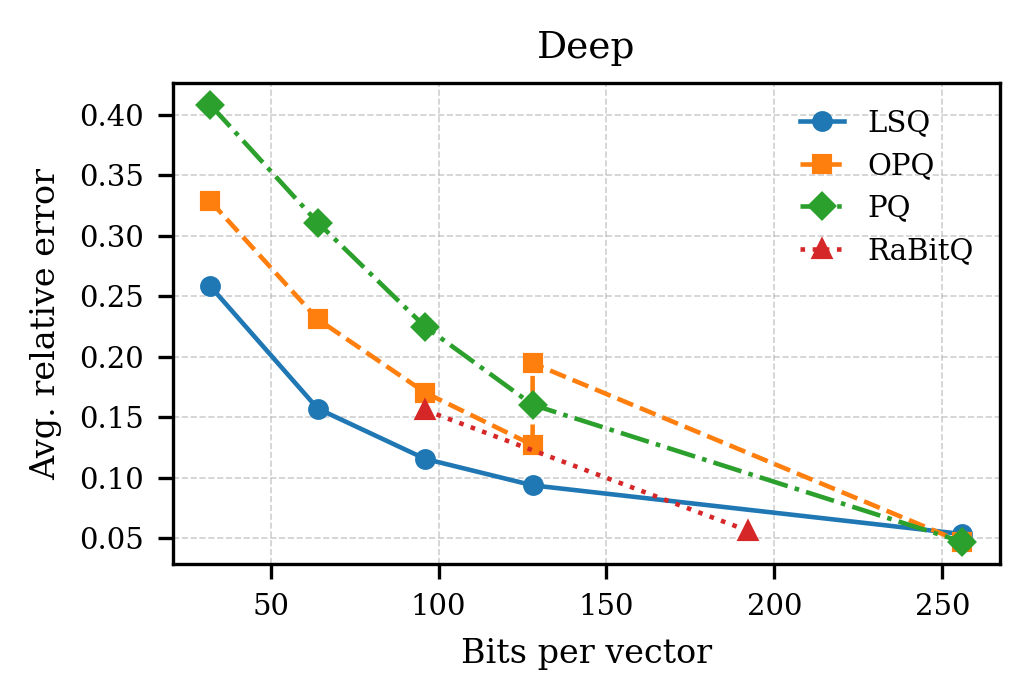

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# === Settings ===
dataset_name = 'Deep'
df = pd.read_csv("/data/cpanourg/2-hdvc/results/relerr/deep_adc_vs_exact_eval.csv")
df = df.sort_values(["method", "bits_per_vector"])

# Matplotlib style adjustments (publication-friendly)
plt.rcParams.update({
    "font.size": 8,
    "font.family": "serif",
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "figure.dpi": 300,
})

# Distinct markers and line styles for B/W compatibility
markers = ['o', 's', 'D', '^', 'v', 'P', '*', 'X']
linestyles = ['-', '--', '-.', ':']

fig, ax = plt.subplots(figsize=(3.3, 2.2))  # good size for 2-column layout

# === Plot each method ===
for i, (method, group) in enumerate(df.groupby("method")):
    color = plt.cm.tab10.colors[i % 10]
    marker = markers[i % len(markers)]
    linestyle = linestyles[i % len(linestyles)]

    ax.plot(
        group["bits_per_vector"],
        group["rel_error_mean"],
        linestyle=linestyle,
        marker=marker,
        markersize=4,
        linewidth=1.1,
        label=method,
        color=color,
    )

# === Axes, labels, grid, legend ===
ax.set_xlabel("Bits per vector")
ax.set_ylabel("Avg. relative error")
ax.set_title(dataset_name)
ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)
ax.legend(
    # title="Methods",
    frameon=False,
    loc="upper right",
    handlelength=1.5
)

plt.tight_layout(pad=0.3)
plt.show()
